# Training Data Models on Processed Collections

This notebook trains 3610 models for each collection in `processed_collections`:
- Binary collections: **em_collection**, **f1_binary_collection**, **rougel_binary_collection** → Logistic Regression
- Continuous collections: **f1_collection**, **rougel_collection** → Linear Regression

Models are trained with different features and saved weights as tensors.

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc
import torch
import os
import json
from pathlib import Path
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, mean_absolute_error
from tqdm import tqdm
from numpy import float64
from utils.set_random_seed import set_random_seed

# Set random seed for reproducibility
set_random_seed(42)

# Configuration
BASE_PATH = Path(".")
PROCESSED_COLLECTIONS_PATH = BASE_PATH / "processed_collections"
WEIGHTS_OUTPUT_PATH = BASE_PATH / "weights" / "runs"

# Define collections: binary vs continuous
# em_collection is binary, f1 and rougel can be either
BINARY_COLLECTIONS = ["em_collection", "f1_binary_collection", "rougel_binary_collection"]
CONTINUOUS_COLLECTIONS = ["f1_collection", "rougel_collection"]
ALL_COLLECTIONS = BINARY_COLLECTIONS + CONTINUOUS_COLLECTIONS

print(f"Binary collections: {BINARY_COLLECTIONS}")
print(f"Continuous collections: {CONTINUOUS_COLLECTIONS}")
print(f"Total collections: {len(ALL_COLLECTIONS)}")

Binary collections: ['em_collection', 'f1_binary_collection', 'rougel_binary_collection']
Continuous collections: ['f1_collection', 'rougel_collection']
Total collections: 5


## Data Loading

Load training and test sets from processed collections.

In [2]:
def load_collection_data(collection_name, split="train"):
    """
    Load a collection's data from feather files.
    
    Args:
        collection_name: Name of the collection
        split: "train" or "test"
    
    Returns:
        DataFrame with columns: input, evaluation, and other metadata
    """
    file_path = PROCESSED_COLLECTIONS_PATH / collection_name / f"{split}.feather"
    if not file_path.exists():
        print(f"Warning: {file_path} not found")
        return None
    return pl.read_ipc(str(file_path))

# Load all collections
collections_data = {}
for collection in ALL_COLLECTIONS:
    print(f"\nLoading {collection}...")
    train_df = load_collection_data(collection, "train").sort("test_idx", "collection_idx")
    test_df = load_collection_data(collection, "test").sort("test_idx", "collection_idx")
    
    if train_df is not None and test_df is not None:
        collections_data[collection] = {
            "train": train_df,
            "test": test_df,
            "is_binary": collection in BINARY_COLLECTIONS
        }
        print(f"  Train shape: {train_df.shape}")
        print(f"  Test shape: {test_df.shape}")
        print(f"  Is binary: {collections_data[collection]['is_binary']}")
    else:
            print(f"  Failed to load {collection}")


Loading em_collection...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (7220000, 4)
  Test shape: (722000, 4)
  Is binary: True

Loading f1_binary_collection...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (7220000, 4)
  Test shape: (722000, 4)
  Is binary: True

Loading rougel_binary_collection...


...

  Train shape: (6925000, 4)
  Test shape: (722000, 4)
  Is binary: True

Loading f1_collection...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (7220000, 4)
  Test shape: (722000, 4)
  Is binary: False

Loading rougel_collection...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (6925000, 4)
  Test shape: (722000, 4)
  Is binary: False


## Model Training

Train models for all collections. For each collection, we train N models by stratifying the data into different groups.

**Binary Collections**: Use `LogisticRegression` with cross-validated hyperparameters
**Continuous Collections**: Use `LinearRegression` for regression tasks

In [ ]:
def load_best_params(collection_name):
    """
    Load best hyperparameters from gridsearch JSON files.
    
    Args:
        collection_name: Name of the collection
    
    Returns:
        List of best_params dictionaries, one for each model
    """
    params_file = PROCESSED_COLLECTIONS_PATH.parent / "hyperparameter_tuning" / f"best_params_gridsearch_{collection_name}.json"
    
    if not params_file.exists():
        print(f"Warning: Hyperparameter file not found at {params_file}")
        return None
    
    with open(params_file, "r") as f:
        data = json.load(f)
    
    best_params_list = []
    for result in data["results"]:
        if "best_params" in result:
            best_params_list.append(result["best_params"])
        else:
            best_params_list.append(None)
    
    print(f"Loaded {len(best_params_list)} hyperparameter sets for {collection_name}")
    return best_params_list

def prepare_data_splits(df, num_models=3610):
    """
    Prepare stratified data splits for training multiple models.
    
    Creates `num_models` different subsamples by splitting the input data
    into stratified groups. Each model gets a different subset of features.
    
    Args:
        df: DataFrame with 'input' and 'evaluation' columns
        num_models: Number of models to train
    
    Returns:
        Lists of (X_train, y_train) tuples for each model
    """
    
    # Create stratified splits
    X_splits = []
    y_splits = []
    
    for i in range(num_models):
        X = df.filter(pl.col("test_idx") == i).select("input").to_numpy()
        X = np.array([i[0] for i in X])
        y = df.filter(pl.col("test_idx") == i).select("evaluation").to_numpy()
        
        X_splits.append(X)
        y_splits.append(y)
    
    return X_splits, y_splits

def train_collection_models(collection_name, num_models=3610):
    """
    Train all models for a specific collection.
    
    Args:
        collection_name: Name of the collection
        num_models: Number of models to train
    
    Returns:
        Dictionary with trained models, evaluations, and metadata
    """
    if collection_name not in collections_data:
        print(f"Collection {collection_name} not loaded")
        return None
    
    is_binary = collections_data[collection_name]["is_binary"]
    train_df = collections_data[collection_name]["train"]
    test_df = collections_data[collection_name]["test"]
    
    print(f"\n{'='*60}")
    print(f"Training {num_models} models for {collection_name}")
    print(f"Type: {'Binary Classification' if is_binary else 'Regression'}")
    print(f"{'='*60}")
    
    # Load best hyperparameters for binary collections
    best_params_list = None
    if is_binary:
        best_params_list = load_best_params(collection_name)
    
    # Prepare data splits
    X_train, y_train = prepare_data_splits(train_df, num_models)
    X_test, y_test = prepare_data_splits(test_df, num_models)
    
    models = []
    evaluations = []
    count_errors = 0
    
    # Train models
    with tqdm(total=num_models, desc=f"Training {collection_name}") as pbar:
        for i in range(num_models):
            model = None
            
            if is_binary:
                # Binary classification: LogisticRegression with best params
                if best_params_list and i < len(best_params_list) and best_params_list[i] is not None:
                    # Use gridsearch best params
                    params = best_params_list[i].copy()
                    # Handle l1_ratio for solvers that don't support it
                    if params.get("solver") in ["lbfgs", "newton-cg"]:
                        params.pop("l1_ratio", None)
                    model = LogisticRegression(
                        random_state=42,
                        n_jobs=-1,
                        **params
                    )
                else:
                    # Fallback to default params
                    model = LogisticRegression(
                        max_iter=1000,
                        random_state=42,
                        solver='lbfgs',
                        n_jobs=-1
                    )
            else:
                # Regression: LinearRegression
                model = LinearRegression(n_jobs=-1)
            
            # Train on this split
            try:
                model.fit(X_train[i], y_train[i].ravel())
            except Exception as e:
                model = None
                count_errors += 1
            
            # Evaluate only if model was successfully trained
            if model is not None:
                try:
                    if is_binary:
                        # AUC score for binary classification
                        y_pred_proba = model.predict_proba(X_test[i])[:, 1]
                        score = roc_auc_score(y_test[i].ravel(), y_pred_proba)
                        eval_metric = "auc"
                    else:
                        # MAE for regression
                        y_pred = model.predict(X_test[i])
                        score = mean_absolute_error(y_test[i].ravel(), y_pred)
                        eval_metric = "mae"
                    
                    evaluations.append({
                        "model_idx": i,
                        "score": score,
                        "metric": eval_metric,
                        "n_features": X_train[i].shape[1],
                        "n_train_samples": len(X_train[i]),
                        "n_test_samples": len(X_test[i])
                    })
                except Exception as e:
                    # Evaluation failed, append None record
                    evaluations.append({
                        "model_idx": i,
                        "score": None,
                        "metric": "failed",
                        "n_features": X_train[i].shape[1],
                        "n_train_samples": len(X_train[i]),
                        "n_test_samples": len(X_test[i])
                    })
            else:
                # No model was trained, append None record
                evaluations.append({
                    "model_idx": i,
                    "score": None,
                    "metric": "failed",
                    "n_features": X_train[i].shape[1],
                    "n_train_samples": len(X_train[i]),
                    "n_test_samples": len(X_test[i])
                })
            
            # Always append model and update progress bar
            models.append(model)
            pbar.update(1)
    
    print(f"  Total errors: {count_errors}/{num_models}")
    return {
        "models": models,
        "evaluations": evaluations,
        "is_binary": is_binary,
        "collection_name": collection_name,
        "num_models": num_models
    }

# Train models for all collections
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings


all_trained_models = {}
for collection in ALL_COLLECTIONS:
    result = train_collection_models(collection, num_models=3610)
    if result is not None:
        all_trained_models[collection] = result
    gc.collect()


Training 3610 models for em_collection
Type: Binary Classification
Loaded 3610 hyperparameter sets for em_collection


Training em_collection: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [02:45<00:00, 21.78it/s]


  Total errors: 666/3610

Training 3610 models for f1_binary_collection
Type: Binary Classification
Loaded 3610 hyperparameter sets for f1_binary_collection


Training f1_binary_collection: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [03:23<00:00, 17.76it/s]


  Total errors: 177/3610

Training 3610 models for rougel_binary_collection
Type: Binary Classification
Loaded 3610 hyperparameter sets for rougel_binary_collection


Training rougel_binary_collection: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [03:18<00:00, 18.14it/s]


  Total errors: 148/3610

Training 3610 models for f1_collection
Type: Regression


Training f1_collection: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [01:29<00:00, 40.40it/s]


  Total errors: 0/3610

Training 3610 models for rougel_collection
Type: Regression


Training rougel_collection:   9%|████████████▊                                                                                                                                       | 313/3610 [00:08<01:21, 40.58it/s]

## Saving Model Weights

Save trained model weights as PyTorch tensors to the `weights/runs` directory.

In [21]:
def save_model_weights(training_results):
    """
    Save model weights and biases as:
    1. PyTorch tensors in weights/runs/[collection_name]/
    2. Feather format in runs/datamodels/models/[collection_prefix]/0_3609_weights.feather
    
    Args:
        training_results: Dictionary containing trained models and metadata
    """
    collection_name = training_results["collection_name"]
    models = training_results["models"]
    is_binary = training_results["is_binary"]
    
    # Extract collection prefix (remove _collection or _binary_collection suffix)
    if collection_name.endswith("_collection"):
        collection_prefix = collection_name.replace("_collection", "")
    else:
        collection_prefix = collection_name
    
    # Create output directories
    output_dir_pt = WEIGHTS_OUTPUT_PATH / collection_name
    output_dir_pt.mkdir(parents=True, exist_ok=True)
    
    output_dir_feather = BASE_PATH / "runs" / "datamodels" / "models" / collection_prefix
    output_dir_feather.mkdir(parents=True, exist_ok=True)
    
    print(f"\nSaving weights for {collection_name}...")
    
    # Extract weights and biases
    weights_list = []
    bias_list = []
    
    for i, model in enumerate(models):
        if model is not None:
            if is_binary:
                # Logistic Regression: coef_ has shape (1, n_features)
                weights_list.append(model.coef_[0])
                bias_list.append(float(model.intercept_))
            else:
                # Linear Regression: coef_ has shape (n_features,)
                weights_list.append(model.coef_)
                bias_list.append(float(model.intercept_))
        else:
            weights_list.append(np.concatenate([np.ones(16), np.zeros(84)]))
            bias_list.append(0.0)
    
    # Convert to tensors
    weights_tensor = torch.tensor(weights_list, dtype=torch.float32)
    bias_tensor = torch.tensor(bias_list, dtype=torch.float32)
    
    # Save as PyTorch tensors in weights/runs
    weights_file_pt = output_dir_pt / "weights.pt"
    bias_file_pt = output_dir_pt / "bias.pt"
    
    torch.save(weights_tensor, str(weights_file_pt))
    torch.save(bias_tensor, str(bias_file_pt))
    
    print(f"  PyTorch format:")
    print(f"    Weights shape: {weights_tensor.shape}")
    print(f"    Bias shape: {bias_tensor.shape}")
    print(f"    Saved to: {output_dir_pt}")
    
    # Save as Feather in runs/datamodels/models
    weights_file_datamodels = output_dir_feather / "0_3609_weights.pt"
    torch.save(weights_tensor, str(weights_file_datamodels))


    print(f"  Feather format:")
    print(f"    Saved to: {weights_file_datamodels}")
    
    return {
        "weights_file_pt": str(weights_file_pt),
        "bias_file_pt": str(bias_file_pt),
        "weights_file_feather": str(weights_file_datamodels),
        "weights_shape": weights_tensor.shape,
        "bias_shape": bias_tensor.shape
    }

# Save weights for all trained collections
saved_weights = {}
for collection_name, training_results in all_trained_models.items():
    save_result = save_model_weights(training_results)
    saved_weights[collection_name] = save_result



Saving weights for em_collection...
  PyTorch format:
    Weights shape: torch.Size([3610, 100])
    Bias shape: torch.Size([3610])
    Saved to: weights/runs/em_collection
  Feather format:
    Saved to: runs/datamodels/models/em/0_3609_weights.pt

Saving weights for f1_binary_collection...
  PyTorch format:
    Weights shape: torch.Size([3610, 100])
    Bias shape: torch.Size([3610])
    Saved to: weights/runs/f1_binary_collection
  Feather format:
    Saved to: runs/datamodels/models/f1_binary/0_3609_weights.pt

Saving weights for rougel_binary_collection...
  PyTorch format:
    Weights shape: torch.Size([3610, 100])
    Bias shape: torch.Size([3610])
    Saved to: weights/runs/rougel_binary_collection
  Feather format:
    Saved to: runs/datamodels/models/rougel_binary/0_3609_weights.pt

Saving weights for f1_collection...
  PyTorch format:
    Weights shape: torch.Size([3610, 100])
    Bias shape: torch.Size([3610])
    Saved to: weights/runs/f1_collection
  Feather format:
    

## Evaluation and Analysis

Analyze the performance metrics across all trained models and collections.

In [22]:
def create_evaluation_summary(training_results):
    """
    Create a summary of evaluation metrics for a collection.
    
    Args:
        training_results: Dictionary containing training results
    
    Returns:
        DataFrame with summary statistics
    """
    collection_name = training_results["collection_name"]
    is_binary = training_results["is_binary"]
    evaluations = training_results["evaluations"]
    
    # Convert to DataFrame
    eval_df = pl.DataFrame(evaluations)
    
    # Calculate statistics - filter out NaN values
    valid_scores = eval_df.filter(pl.col("score").is_not_null() & pl.col("score").is_not_nan())
    
    if len(valid_scores) > 0:
        stats = {
            "collection": collection_name,
            "type": "Binary Classification" if is_binary else "Regression",
            "metric": eval_df[0]["metric"],  # Get metric from original df
            "num_models": len(evaluations),
            "successful_models": len(valid_scores),
            "mean_score": valid_scores.select(pl.col("score").mean())[0, 0],
            "std_score": valid_scores.select(pl.col("score").std())[0, 0],
            "min_score": valid_scores.select(pl.col("score").min())[0, 0],
            "max_score": valid_scores.select(pl.col("score").max())[0, 0],
        }
    else:
        stats = {
            "collection": collection_name,
            "type": "Binary Classification" if is_binary else "Regression",
            "metric": "N/A",
            "num_models": len(evaluations),
            "successful_models": 0,
            "mean_score": None,
            "std_score": None,
            "min_score": None,
            "max_score": None,
        }
    
    return stats

# Generate evaluation summaries
all_summaries = []
for collection_name, training_results in all_trained_models.items():
    summary = create_evaluation_summary(training_results)
    all_summaries.append(summary)
    print(f"\n{collection_name}:")
    for key, value in summary.items():
        if key not in ["collection", "type", "metric"]:
            if isinstance(value, float):
                print(f"  {key}: {value:.4f}")
            else:
                print(f"  {key}: {value}")

# Create summary table
summary_df = pl.DataFrame(all_summaries)
print("\n" + "="*80)
print("Summary Table")
print("="*80)
print(summary_df)



em_collection:
  num_models: 3610
  successful_models: 2621
  mean_score: 0.8204
  std_score: 0.1503
  min_score: 0.0251
  max_score: 1.0000

f1_binary_collection:
  num_models: 3610
  successful_models: 3293
  mean_score: 0.8001
  std_score: 0.1383
  min_score: 0.1813
  max_score: 1.0000

rougel_binary_collection:
  num_models: 3610
  successful_models: 3342
  mean_score: 0.7863
  std_score: 0.1418
  min_score: 0.1407
  max_score: 1.0000

f1_collection:
  num_models: 3610
  successful_models: 3610
  mean_score: 0.1547
  std_score: 0.1124
  min_score: 0.0000
  max_score: 0.4627

rougel_collection:
  num_models: 3610
  successful_models: 3610
  mean_score: 0.1569
  std_score: 0.1101
  min_score: 0.0000
  max_score: 0.4598

Summary Table
shape: (5, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ collectio ┆ type      ┆ metric    ┆ num_model ┆ … ┆ mean_scor ┆ std_score ┆ min_score ┆ max_scor │
│ n         ┆ ---       ┆ ---       ┆

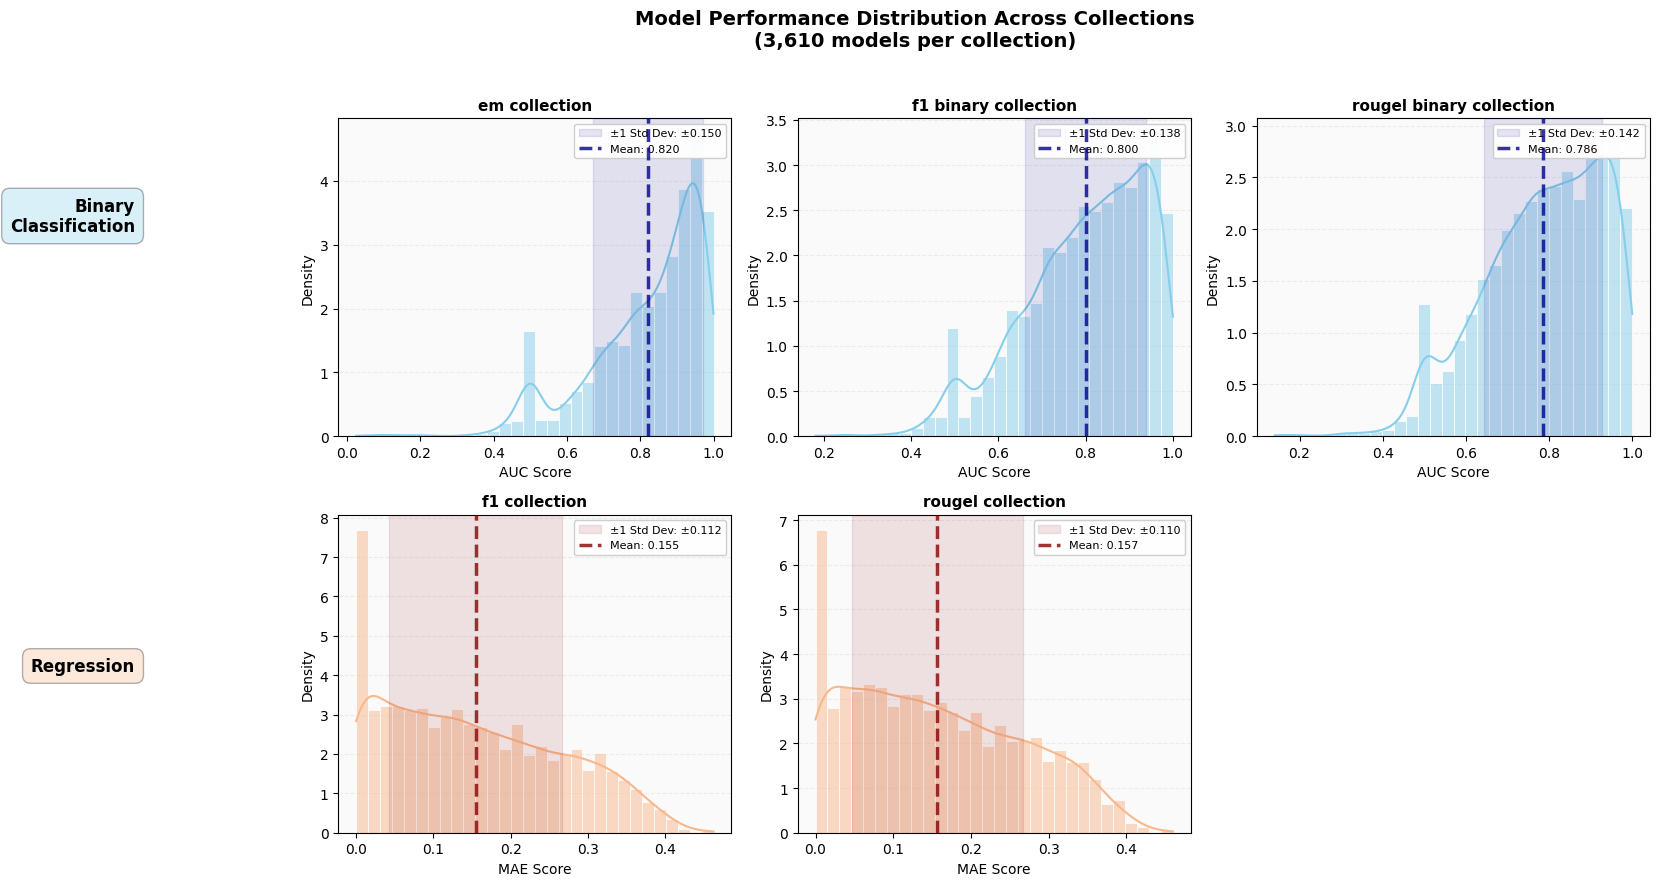

In [23]:
# Visualize performance distribution by collection
# Organized by model type: Binary Classification vs Regression (Storytelling with Data approach)

# Separate collections by type
binary_collections = [c for c in ALL_COLLECTIONS if c in all_trained_models and all_trained_models[c]["is_binary"]]
regression_collections = [c for c in ALL_COLLECTIONS if c in all_trained_models and not all_trained_models[c]["is_binary"]]

# Create subplots: 2 rows (Binary, Regression), adaptive columns
num_cols = max(len(binary_collections), len(regression_collections))
fig, axes = plt.subplots(2, num_cols, figsize=(5*num_cols, 9))

# Ensure axes is always 2D
if num_cols == 1:
    axes = axes.reshape(2, 1)

colors = {"Binary Classification": "#87CEEB", "Regression": "#F8B88B"}

# ============ ROW 0: BINARY CLASSIFICATION (AUC) ============
for idx, collection_name in enumerate(binary_collections):
    training_results = all_trained_models[collection_name]
    eval_df = pl.DataFrame(training_results["evaluations"])
    valid_scores = eval_df.filter(pl.col("score").is_not_null() & pl.col("score").is_not_nan())
    
    if len(valid_scores) > 0:
        sns.histplot(
            data=valid_scores.select("score").to_pandas(),
            x="score",
            bins=30,
            color=colors["Binary Classification"],
            kde=True,
            ax=axes[0, idx],
            stat="density",
            edgecolor='white',
            linewidth=0.5
        )
        axes[0, idx].set_title(f"{collection_name.replace('_', ' ')}", fontsize=11, fontweight='bold')
        axes[0, idx].set_xlabel("AUC Score", fontsize=10)
        axes[0, idx].set_ylabel("Density", fontsize=10)
        axes[0, idx].grid(axis='y', alpha=0.2, linestyle='--')
        axes[0, idx].set_axisbelow(True)
        axes[0, idx].set_facecolor('#fafafa')
        
        # Add mean and standard deviation
        mean_score = valid_scores.select(pl.col("score").mean())[0, 0]
        std_score = valid_scores.select(pl.col("score").std())[0, 0]
        
        # Add standard deviation area (±1 std)
        axes[0, idx].axvspan(mean_score - std_score, mean_score + std_score, 
                            color='darkblue', alpha=0.1, label=f'±1 Std Dev: ±{std_score:.3f}', zorder=5)
        
        # Add mean line
        axes[0, idx].axvline(mean_score, color='darkblue', linestyle='--', linewidth=2.5, alpha=0.8, 
                            label=f'Mean: {mean_score:.3f}', zorder=10)
        axes[0, idx].legend(loc='upper right', fontsize=8, framealpha=0.95)

# Hide unused axes in row 0
for idx in range(len(binary_collections), num_cols):
    axes[0, idx].axis('off')

# ============ ROW 1: REGRESSION (MAE) ============
for idx, collection_name in enumerate(regression_collections):
    training_results = all_trained_models[collection_name]
    eval_df = pl.DataFrame(training_results["evaluations"])
    valid_scores = eval_df.filter(pl.col("score").is_not_null() & pl.col("score").is_not_nan())
    
    if len(valid_scores) > 0:
        sns.histplot(
            data=valid_scores.select("score").to_pandas(),
            x="score",
            bins=30,
            color=colors["Regression"],
            kde=True,
            ax=axes[1, idx],
            stat="density",
            edgecolor='white',
            linewidth=0.5
        )
        axes[1, idx].set_title(f"{collection_name.replace('_', ' ')}", fontsize=11, fontweight='bold')
        axes[1, idx].set_xlabel("MAE Score", fontsize=10)
        axes[1, idx].set_ylabel("Density", fontsize=10)
        axes[1, idx].grid(axis='y', alpha=0.2, linestyle='--')
        axes[1, idx].set_axisbelow(True)
        axes[1, idx].set_facecolor('#fafafa')
        
        # Add mean and standard deviation
        mean_score = valid_scores.select(pl.col("score").mean())[0, 0]
        std_score = valid_scores.select(pl.col("score").std())[0, 0]
        
        # Add standard deviation area (±1 std)
        axes[1, idx].axvspan(mean_score - std_score, mean_score + std_score, 
                            color='darkred', alpha=0.1, label=f'±1 Std Dev: ±{std_score:.3f}', zorder=5)
        
        # Add mean line
        axes[1, idx].axvline(mean_score, color='darkred', linestyle='--', linewidth=2.5, alpha=0.8, 
                            label=f'Mean: {mean_score:.3f}', zorder=10)
        axes[1, idx].legend(loc='upper right', fontsize=8, framealpha=0.95)

# Hide unused axes in row 1
for idx in range(len(regression_collections), num_cols):
    axes[1, idx].axis('off')

# Main title with context
fig.suptitle('Model Performance Distribution Across Collections\n(3,610 models per collection)', 
             fontsize=14, fontweight='bold', y=0.98)

# Add row labels outside plot area (left margin)
fig.text(-0.02, 0.75, 'Binary\nClassification', va='center', ha='right', fontsize=12, fontweight='bold', 
         bbox=dict(boxstyle='round', facecolor=colors["Binary Classification"], alpha=0.3, pad=0.5))
fig.text(-0.02, 0.25, 'Regression', va='center', ha='right', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor=colors["Regression"], alpha=0.3, pad=0.5))

plt.tight_layout(rect=[0.08, 0, 1, 0.96])
plt.show()